# Summary table
Mika - love today

## 1. Import CSV and find pattern.

In [1]:
def parse_classification_filename(filepath):
    """
    Extract metadata from classification table CSV filenames.
 
    Handles:
    1. SVM filenames:
       JYXFE_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01_Test_classification_table.csv

    2. Decision Tree / Random Forest filenames:
       PAT-JYXFE_Test_-_Decision_Tree_classification_table.csv

    Rule:
    Decision Tree and Random Forest are always PCA-based.
    """

    name = Path(filepath).name

    # -------------------------------------------------
    # Pattern 1: SVM
    # -------------------------------------------------
    svm_pattern = re.match(
        r"(?P<patient_id>.+?)_IN-(?P<input_type>FEATURES|PCA)_"
        r"(?P<model>SVM)-SCORING-(?P<scoring>.+?)_"
        r"(?P<date>\d{8})_(?P<version>v\d+)_(?P<dataset>Test|Validation)_classification_table\.csv",
        name
    )

    if svm_pattern:
        info = svm_pattern.groupdict()

        info["model"] = "SVM"
        info["model_group"] = f"{info['input_type']} + SVM"
        info["filename"] = name
        info["filepath"] = str(filepath)
        info["parse_error"] = False

        return info

    # -------------------------------------------------
    # Pattern 2: Decision Tree / Random Forest
    # -------------------------------------------------
    tree_rf_pattern = re.match(
        r"PAT-(?P<patient_id>.+?)_"
        r"(?P<dataset>Test|Validation)_-_"
        r"(?P<model>Decision_Tree|Random_Forest)_classification_table\.csv",
        name
    )

    if tree_rf_pattern:
        info = tree_rf_pattern.groupdict()

        # Fixed rule: DT and RF are always PCA-based
        info["input_type"] = "PCA"
        info["model"] = info["model"].replace("_", " ")
        info["scoring"] = None
        info["date"] = None
        info["version"] = None
        info["model_group"] = f"{info['input_type']} + {info['model']}"
        info["filename"] = name
        info["filepath"] = str(filepath)
        info["parse_error"] = False

        return info

    # -------------------------------------------------
    # If no pattern matched
    # -------------------------------------------------
    return {
        "patient_id": None,
        "input_type": None,
        "model": None,
        "scoring": None,
        "date": None,
        "version": None,
        "dataset": None,
        "model_group": None,
        "filename": name,
        "filepath": str(filepath),
        "parse_error": True
    }

In [2]:
from pathlib import Path
import pandas as pd
import re

# ============================================================
# 1. Define folder containing all classification table CSVs
# ============================================================

classification_tables_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/classification_tables"
)

# Load all CSV paths in that folder
csv_files = sorted(classification_tables_dir.glob("*classification_table.csv"))

print(f"Number of CSV files found: {len(csv_files)}")

for file in csv_files:
    print(file.name)

Number of CSV files found: 72
10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_20260612_v01_Test_classification_table.csv
10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_20260612_v01_Validation_classification_table.csv
10OXG_IN-PCA_SVM-SCORING-F1-MACRO_20260612_v01_Test_classification_table.csv
10OXG_IN-PCA_SVM-SCORING-F1-MACRO_20260612_v01_Validation_classification_table.csv
1JSZ6_IN-FEATURES_SVM-SCORING-F1-MACRO_20260616_v01_Test_classification_table.csv
1JSZ6_IN-FEATURES_SVM-SCORING-F1-MACRO_20260616_v01_Validation_classification_table.csv
1JSZ6_IN-PCA_SVM-SCORING-F1-MACRO_20260616_v01_Test_classification_table.csv
1JSZ6_IN-PCA_SVM-SCORING-F1-MACRO_20260616_v01_Validation_classification_table.csv
3ZL8B_IN-FEATURES_SVM-SCORING-F1-MACRO_20260612_v01_Test_classification_table.csv
3ZL8B_IN-FEATURES_SVM-SCORING-F1-MACRO_20260612_v01_Validation_classification_table.csv
3ZL8B_IN-PCA_SVM-SCORING-F1-MACRO_20260612_v01_Test_classification_table.csv
3ZL8B_IN-PCA_SVM-SCORING-F1-MACRO_20260612_v01_Validation_class

In [3]:
metadata_df = pd.DataFrame([
    parse_classification_filename(file)
    for file in csv_files
])

metadata_df

,patient_id,input_type,model,scoring,date,version,dataset,model_group,filename,filepath,parse_error
0,10OXG,FEATURES,SVM,F1-MACRO,20260612,v01,Test,FEATURES + SVM,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
1,10OXG,FEATURES,SVM,F1-MACRO,20260612,v01,Validation,FEATURES + SVM,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
2,10OXG,PCA,SVM,F1-MACRO,20260612,v01,Test,PCA + SVM,10OXG_IN-PCA_SVM-SCORING-F1-MACRO_20260612_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
3,10OXG,PCA,SVM,F1-MACRO,20260612,v01,Validation,PCA + SVM,10OXG_IN-PCA_SVM-SCORING-F1-MACRO_20260612_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
4,1JSZ6,FEATURES,SVM,F1-MACRO,20260616,v01,Test,FEATURES + SVM,1JSZ6_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
...,...,...,...,...,...,...,...,...,...,...,...
67,RQXZ1,PCA,SVM,F1-MACRO,20260608,v01,Validation,PCA + SVM,RQXZ1_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
68,XB47Y,FEATURES,SVM,F1-MACRO,20260608,v01,Test,FEATURES + SVM,XB47Y_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
69,XB47Y,FEATURES,SVM,F1-MACRO,20260608,v01,Validation,FEATURES + SVM,XB47Y_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False
70,XB47Y,PCA,SVM,F1-MACRO,20260608,v01,Test,PCA + SVM,XB47Y_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...,False


In [4]:
metadata_df.groupby(["dataset", "model_group"]).size()

dataset     model_group        
Test        FEATURES + SVM         9
            PCA + Decision Tree    9
            PCA + Random Forest    9
            PCA + SVM              9
Validation  FEATURES + SVM         9
            PCA + Decision Tree    9
            PCA + Random Forest    9
            PCA + SVM              9
dtype: int64

## 2. Read CSV to build summary df: add data to the metadata_df


In [5]:
import pandas as pd
from pathlib import Path

# ============================================================
# 1. Function to extract one metric from one classification CSV
# ============================================================

def extract_classification_metric(
    csv_path,
    metric_row="weighted avg",
    metric_col="f1-score"
):
    """
    Extracts one value from a classification table CSV.

    Example:
    metric_row = "weighted avg"
    metric_col = "f1-score"
    """

    csv_path = Path(csv_path)

    df = pd.read_csv(csv_path)

    # Remove accidental unnamed index columns if present
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Safety check
    if "class_or_metric" not in df.columns:
        raise ValueError(
            f"'class_or_metric' column not found in {csv_path.name}. "
            f"Columns found: {list(df.columns)}"
        )

    if metric_col not in df.columns:
        raise ValueError(
            f"'{metric_col}' column not found in {csv_path.name}. "
            f"Columns found: {list(df.columns)}"
        )

    # Normalize labels to avoid problems with spaces/capitalization
    df["class_or_metric_clean"] = (
        df["class_or_metric"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    metric_row_clean = metric_row.strip().lower()

    metric_match = df[df["class_or_metric_clean"] == metric_row_clean]

    if metric_match.empty:
        raise ValueError(
            f"Metric row '{metric_row}' not found in {csv_path.name}. "
            f"Rows found: {df['class_or_metric'].tolist()}"
        )

    value = metric_match[metric_col].iloc[0]

    return float(value)

In [6]:
# ============================================================
# 2. Build summary dataframe
# ============================================================

def build_summary_df(
    metadata_df,
    metric_row="weighted avg",
    metric_col="f1-score"
):
    """
    Builds one summary dataframe from all classification table CSV files.

    Each CSV becomes one row in the output dataframe.
    """

    summary_rows = []

    for _, row in metadata_df.iterrows():

        # Skip files that were not parsed correctly
        if row.get("parse_error", False):
            continue

        csv_path = row["filepath"]

        metric_value = extract_classification_metric(
            csv_path=csv_path,
            metric_row=metric_row,
            metric_col=metric_col
        )

        summary_rows.append({
            "patient_id": row["patient_id"],
            "dataset": row["dataset"],
            "input_type": row["input_type"],
            "model": row["model"],
            "model_group": row["model_group"],
            "metric_row": metric_row,
            "metric_col": metric_col,
            "metric_value": metric_value,
            "filename": row["filename"],
            "filepath": row["filepath"]
        })

    summary_df = pd.DataFrame(summary_rows)

    return summary_df

In [7]:
summary_df = build_summary_df(
    metadata_df=metadata_df,
    metric_row="weighted avg",
    metric_col="f1-score"
)
summary_df = summary_df.rename(columns={"metric_value": "weighted_f1"})



summary_df

,patient_id,dataset,input_type,model,model_group,metric_row,metric_col,weighted_f1,filename,filepath
0,10OXG,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.810780,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
1,10OXG,Validation,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.621687,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
2,10OXG,Test,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.801770,10OXG_IN-PCA_SVM-SCORING-F1-MACRO_20260612_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
3,10OXG,Validation,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.623689,10OXG_IN-PCA_SVM-SCORING-F1-MACRO_20260612_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
4,1JSZ6,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.752007,1JSZ6_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
...,...,...,...,...,...,...,...,...,...,...
67,RQXZ1,Validation,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.494577,RQXZ1_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
68,XB47Y,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.631620,XB47Y_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
69,XB47Y,Validation,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.701226,XB47Y_IN-FEATURES_SVM-SCORING-F1-MACRO_2026060...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
70,XB47Y,Test,PCA,SVM,PCA + SVM,weighted avg,f1-score,0.593246,XB47Y_IN-PCA_SVM-SCORING-F1-MACRO_20260608_v01...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...


In [8]:
model_order = [
    "FEATURES + SVM",
    "PCA + SVM",
    "PCA + Decision Tree",
    "PCA + Random Forest",
]

summary_df["model_group"] = pd.Categorical(
    summary_df["model_group"],
    categories=model_order,
    ordered=True
)

summary_df = summary_df.sort_values(
    by=["dataset", "model_group", "patient_id"]
).reset_index(drop=True)

summary_df

,patient_id,dataset,input_type,model,model_group,metric_row,metric_col,weighted_f1,filename,filepath
0,10OXG,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.810780,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
1,1JSZ6,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.752007,1JSZ6_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
2,3ZL8B,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.748718,3ZL8B_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
3,F88R2,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.881740,F88R2_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
4,FP628,Test,FEATURES,SVM,FEATURES + SVM,weighted avg,f1-score,0.876224,FP628_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
...,...,...,...,...,...,...,...,...,...,...
67,FP628,Validation,PCA,Random Forest,PCA + Random Forest,weighted avg,f1-score,0.833699,PAT-FP628_Validation_-_Random_Forest_classific...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
68,JYXFE,Validation,PCA,Random Forest,PCA + Random Forest,weighted avg,f1-score,0.394231,PAT-JYXFE_Validation_-_Random_Forest_classific...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
69,PN12G,Validation,PCA,Random Forest,PCA + Random Forest,weighted avg,f1-score,0.675407,PAT-PN12G_Validation_-_Random_Forest_classific...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
70,RQXZ1,Validation,PCA,Random Forest,PCA + Random Forest,weighted avg,f1-score,0.502674,PAT-RQXZ1_Validation_-_Random_Forest_classific...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

model_order = [
    "FEATURES + SVM",
    "PCA + SVM",
    "PCA + Decision Tree",
    "PCA + Random Forest",
]

def plot_summary_metric(
    summary_df,
    dataset_to_plot="Test",
    y_col="weighted_f1",
    baseline=0.5,
    output_path=None,
    show_plot=True
):
    """
    Plot model comparison points for one dataset.
    Each point represents one patient.

    Also adds:
    - Horizontal dashed baseline
    - Mean per model category
    - Median per model category
    """

    df_plot = summary_df.copy()

    # -------------------------------------------------
    # Filter dataset
    # -------------------------------------------------
    if dataset_to_plot is not None:
        df_plot = df_plot[df_plot["dataset"] == dataset_to_plot].copy()

    # -------------------------------------------------
    # Keep only model groups present in the dataframe
    # -------------------------------------------------
    current_order = [
        model for model in model_order
        if model in df_plot["model_group"].unique()
    ]

    df_plot["model_group"] = pd.Categorical(
        df_plot["model_group"],
        categories=current_order,
        ordered=True
    )

    # -------------------------------------------------
    # Calculate mean and median per category
    # -------------------------------------------------
    stats_df = (
        df_plot
        .groupby("model_group", observed=True)[y_col]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
    )

    print(stats_df)

    # -------------------------------------------------
    # Plot patient-level points
    # -------------------------------------------------
    plt.figure(figsize=(11, 5.5))

    ax = sns.stripplot(
        data=df_plot,
        x="model_group",
        y=y_col,
        order=current_order,
        hue="patient_id",
        jitter=0.18,
        size=8,
        alpha=0.85
    )

    # -------------------------------------------------
    # Horizontal baseline
    # -------------------------------------------------
    ax.axhline(
        y=baseline,
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.7,
        label=f"Baseline = {baseline}"
    )

    # -------------------------------------------------
    # Add mean and median per category
    # -------------------------------------------------
    for i, model_group in enumerate(current_order):

        row = stats_df[stats_df["model_group"] == model_group]

        if row.empty:
            continue

        mean_value = row["mean"].iloc[0]
        median_value = row["median"].iloc[0]

        # Mean: solid short horizontal line
        ax.hlines(
            y=mean_value,
            xmin=i - 0.25,
            xmax=i + 0.25,
            colors="red",
            linestyles="-",
            linewidth=2.5,
            label="Mean" if i == 0 else None
        )

        # Median: dashed short horizontal line
        ax.hlines(
            y=median_value,
            xmin=i - 0.25,
            xmax=i + 0.25,
            colors="blue",
            linestyles="--",
            linewidth=2.5,
            label="Median" if i == 0 else None
        )

        # Text annotation
        ax.text(
            x=i + 0.28,
            y=mean_value,
            s=f"mean={mean_value:.2f}",
            va="center",
            fontsize=9,
            color="red"
        )

        ax.text(
            x=i + 0.28,
            y=median_value,
            s=f"med={median_value:.2f}",
            va="center",
            fontsize=9,
            color="blue"
        )

    # -------------------------------------------------
    # Labels and formatting
    # -------------------------------------------------
    ax.set_title(f"{dataset_to_plot} performance comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Weighted F1-score")
    ax.set_ylim(0, 1)

    plt.xticks(rotation=25, ha="right")

    plt.legend(
        title="Patient / summary",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()

    # -------------------------------------------------
    # Save
    # -------------------------------------------------
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {output_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

           model_group      mean    median  count
0       FEATURES + SVM  0.686646  0.748718      9
1            PCA + SVM  0.653887  0.673944      9
2  PCA + Decision Tree  0.669896  0.669617      9
3  PCA + Random Forest  0.698444  0.747991      9
Plot saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/Test_weighted_f1_summary_plot.png


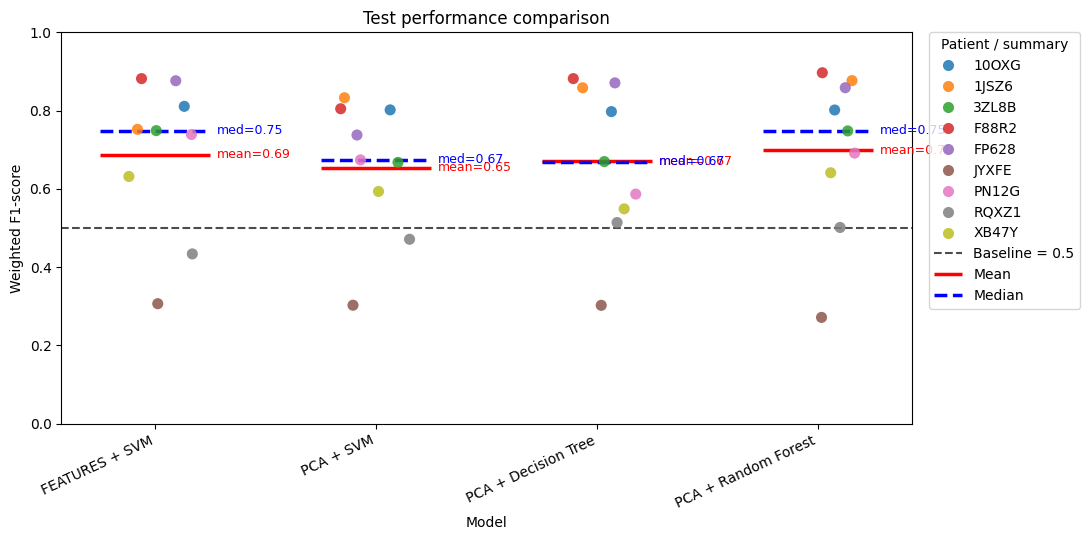

In [12]:
plot_summary_metric(
    summary_df=summary_df,
    dataset_to_plot="Test",
    y_col="weighted_f1",
    baseline=0.5,
    output_path="/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/Test_weighted_f1_summary_plot.png",
    show_plot=True
)

## 3. Plot 3 metrics at the same time: 3 plots (avg, seizure and preictal)

In [10]:
def build_multi_metric_summary_df(metadata_df):
    """
    Builds a long-format summary dataframe with:
    1. weighted avg f1-score
    2. preictal f1-score
    3. seizure f1-score
    """

    metrics_to_extract = [
        {
            "metric_name": "Weighted F1",
            "metric_row": "weighted avg",
            "metric_col": "f1-score"
        },
        {
            "metric_name": "Preictal F1",
            "metric_row": "preictal",
            "metric_col": "f1-score"
        },
        {
            "metric_name": "Seizure F1",
            "metric_row": "seizure",
            "metric_col": "f1-score"
        },
    ]

    summary_rows = []

    for _, row in metadata_df.iterrows():

        if row.get("parse_error", False):
            continue

        csv_path = row["filepath"]

        for metric in metrics_to_extract:

            metric_value = extract_classification_metric(
                csv_path=csv_path,
                metric_row=metric["metric_row"],
                metric_col=metric["metric_col"]
            )

            summary_rows.append({
                "patient_id": row["patient_id"],
                "dataset": row["dataset"],
                "input_type": row["input_type"],
                "model": row["model"],
                "model_group": row["model_group"],
                "metric_name": metric["metric_name"],
                "metric_row": metric["metric_row"],
                "metric_col": metric["metric_col"],
                "metric_value": metric_value,
                "filename": row["filename"],
                "filepath": row["filepath"]
            })

    summary_df_long = pd.DataFrame(summary_rows)

    return summary_df_long

In [11]:
summary_df_long = build_multi_metric_summary_df(metadata_df)

summary_df_long.head()

,patient_id,dataset,input_type,model,model_group,metric_name,metric_row,metric_col,metric_value,filename,filepath
0,10OXG,Test,FEATURES,SVM,FEATURES + SVM,Weighted F1,weighted avg,f1-score,0.810780,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
1,10OXG,Test,FEATURES,SVM,FEATURES + SVM,Preictal F1,preictal,f1-score,0.807339,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
2,10OXG,Test,FEATURES,SVM,FEATURES + SVM,Seizure F1,seizure,f1-score,0.814159,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
3,10OXG,Validation,FEATURES,SVM,FEATURES + SVM,Weighted F1,weighted avg,f1-score,0.621687,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...
4,10OXG,Validation,FEATURES,SVM,FEATURES + SVM,Preictal F1,preictal,f1-score,0.648148,10OXG_IN-FEATURES_SVM-SCORING-F1-MACRO_2026061...,/home/tperezsanchez/Tomas_PS_DissertationKCL20...


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from datetime import date
from matplotlib.lines import Line2D
import re

# ============================================================
# Model order
# ============================================================

model_order = [
    "FEATURES + SVM",
    "PCA + SVM",
    "PCA + Decision Tree",
    "PCA + Random Forest",
]

# ============================================================
# Patient ID mapping
# ============================================================

patient_number_map = {
    "10OXG": "P1",
    "1JSZ6": "P2",
    "3ZL8B": "P3",
    "F88R2": "P4",
    "FP628": "P5",
    "JYXFE": "P6",
    "PN12G": "P7",
    "RQXZ1": "P8",
    "XB47Y": "P9"
}

patient_order = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9"]

# ============================================================
# Patient color palette
# Same palette used in previous patient plots
# ============================================================

CB_color_cycle = [
    "#2E0F4F",  # P1 - very dark violet
    "#FF5F00",  # P2 - very bright orange
    "#1B7837",  # P3 - dark green
    "#f781bf",  # P4 - pink
    "#a65628",  # P5 - brown
    "#984ea3",  # P6 - purple
    "#999999",  # P7 - grey
    "#e41a1c",  # P8 - red
    "#dede00"   # P9 - yellow
]

patient_colors = {
    patient: CB_color_cycle[i]
    for i, patient in enumerate(patient_order)
}

# ============================================================
# Helper function for clean filenames
# ============================================================

def clean_filename(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = text.strip("_")
    return text


# ============================================================
# Main plotting function
# ============================================================

def plot_metric_from_summary_long(
    summary_df_long,
    metric_name,
    dataset_to_plot="Test",
    baseline=0.5,
    output_path=None,
    show_plot=True,
    add_stats_text=True
):
    """
    Plot one metric from summary_df_long.

    Each point represents one patient.

    Uses:
    - Numeric patient labels: P1-P9
    - Same patient color palette used in previous plots
    - Different marker/symbol per patient
    - Fixed horizontal offset per patient to avoid overlap
    - Optional baseline at 0.5
    - Mean/median/n text above the 0-1 metric range
    - Saves plot as SVG
    """

    df_plot = summary_df_long.copy()

    df_plot = df_plot[
        (df_plot["dataset"] == dataset_to_plot) &
        (df_plot["metric_name"] == metric_name)
    ].copy()

    # -------------------------------------------------
    # Convert original patient IDs to numeric patient labels
    # -------------------------------------------------

    df_plot["Patient"] = df_plot["patient_id"].map(patient_number_map)

    unmapped_patients = df_plot.loc[
        df_plot["Patient"].isna(),
        "patient_id"
    ].unique()

    if len(unmapped_patients) > 0:
        print("Warning: these patient IDs were not mapped:", unmapped_patients)

    df_plot = df_plot.dropna(subset=["Patient"])

    df_plot["Patient"] = pd.Categorical(
        df_plot["Patient"],
        categories=patient_order,
        ordered=True
    )

    # -------------------------------------------------
    # Keep model order consistent
    # -------------------------------------------------

    current_order = [
        model for model in model_order
        if model in df_plot["model_group"].unique()
    ]

    df_plot["model_group"] = pd.Categorical(
        df_plot["model_group"],
        categories=current_order,
        ordered=True
    )

    df_plot = df_plot.sort_values(["model_group", "Patient"])

    # -------------------------------------------------
    # Calculate mean and median per category
    # -------------------------------------------------

    stats_df = (
        df_plot
        .groupby("model_group", observed=True)["metric_value"]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
    )

    print(f"\n{dataset_to_plot} - {metric_name}")
    print(stats_df)

    # -------------------------------------------------
    # Patient marker and offset mapping
    # -------------------------------------------------

    present_patients = [
        patient for patient in patient_order
        if patient in df_plot["Patient"].astype(str).unique()
    ]

    markers = ["o", "s", "^", "D", "v", "P", "*", "<", ">"]

    if len(present_patients) > len(markers):
        raise ValueError(
            f"Not enough marker types for {len(present_patients)} patients. "
            f"Add more markers to the markers list."
        )

    patient_to_marker = {
        patient: markers[i]
        for i, patient in enumerate(present_patients)
    }

    # Fixed offsets instead of random jitter
    if len(present_patients) == 1:
        offsets = [0]
    else:
        offsets = np.linspace(-0.16, 0.16, len(present_patients))

    patient_to_offset = {
        patient: offsets[i]
        for i, patient in enumerate(present_patients)
    }

    model_to_x = {
        model: i
        for i, model in enumerate(current_order)
    }

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 5.5))

    # Extra vertical space so the mean/median/n boxes do not overlap patient points
    y_upper = 1.12
    y_stats = 1.09

    for _, row in df_plot.iterrows():

        model_group = row["model_group"]
        patient = str(row["Patient"])
        y_value = row["metric_value"]

        x_value = model_to_x[model_group] + patient_to_offset[patient]

        ax.scatter(
            x_value,
            y_value,
            marker=patient_to_marker[patient],
            s=95,
            facecolors=patient_colors[patient],
            edgecolors="black",
            linewidths=1.2,
            alpha=0.90,
            zorder=3
        )

    # -------------------------------------------------
    # Optional horizontal baseline
    # -------------------------------------------------

    if baseline is not None:
        ax.axhline(
            y=baseline,
            linestyle="--",
            linewidth=1.5,
            color="black",
            alpha=0.7,
            label=f"Baseline = {baseline}",
            zorder=1
        )

    # -------------------------------------------------
    # Add mean and median as text above plot points
    # -------------------------------------------------

    if add_stats_text:
        for i, model_group in enumerate(current_order):

            row = stats_df[stats_df["model_group"] == model_group]

            if row.empty:
                continue

            mean_value = row["mean"].iloc[0]
            median_value = row["median"].iloc[0]
            count_value = int(row["count"].iloc[0])

            stats_text = (
                f"mean={mean_value:.2f}\n"
                f"med={median_value:.2f}\n"
                f"n={count_value}"
            )

            ax.text(
                x=i,
                y=y_stats,
                s=stats_text,
                ha="center",
                va="top",
                fontsize=9,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="gray",
                    alpha=0.8
                ),
                zorder=4
            )

    # -------------------------------------------------
    # Axis formatting
    # -------------------------------------------------

    ax.set_title(f"{dataset_to_plot} - {metric_name}")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric_name)

    # Keep metric range visible while adding space above for stats boxes
    ax.set_ylim(0, y_upper)

    ax.set_xticks(range(len(current_order)))
    ax.set_xticklabels(current_order, rotation=25, ha="right")

    ax.grid(axis="y", linestyle=":", alpha=0.4)

    # -------------------------------------------------
    # Custom legend for patients
    # -------------------------------------------------

    patient_handles = [
        Line2D(
            [0],
            [0],
            marker=patient_to_marker[patient],
            color="w",
            markerfacecolor=patient_colors[patient],
            markeredgecolor="black",
            markeredgewidth=1.2,
            linestyle="None",
            markersize=8,
            label=patient
        )
        for patient in present_patients
    ]

    legend_handles = patient_handles.copy()

    if baseline is not None:
        baseline_handle = Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Baseline = {baseline}"
        )
        legend_handles.append(baseline_handle)

    ax.legend(
        handles=legend_handles,
        title="Patient",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()

    # -------------------------------------------------
    # Save as SVG
    # -------------------------------------------------

    if output_path is None:
        today = date.today().strftime("%Y-%m-%d")
        filename = (
            f"{clean_filename(dataset_to_plot)}_"
            f"{clean_filename(metric_name)}_"
            f"model_comparison_patient_palette_{today}.svg"
        )
        output_path = Path.cwd() / filename
    else:
        output_path = Path(output_path)

        if output_path.suffix.lower() != ".svg":
            output_path = output_path.with_suffix(".svg")

    output_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        output_path,
        format="svg",
        bbox_inches="tight"
    )

    print(f"SVG saved in: {output_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()


Test - Weighted F1
           model_group      mean    median  count
0       FEATURES + SVM  0.686646  0.748718      9
1            PCA + SVM  0.653887  0.673944      9
2  PCA + Decision Tree  0.669896  0.669617      9
3  PCA + Random Forest  0.698444  0.747991      9
SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Test_weighted_f1_summary_plot.svg


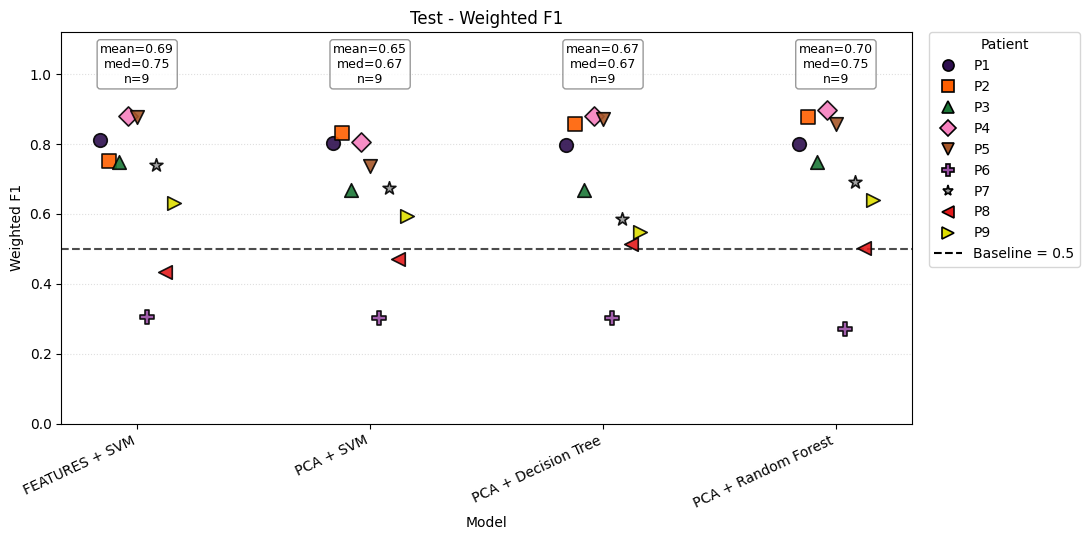


Test - Preictal F1
           model_group      mean    median  count
0       FEATURES + SVM  0.714727  0.745763      9
1            PCA + SVM  0.645675  0.672489      9
2  PCA + Decision Tree  0.662301  0.666667      9
3  PCA + Random Forest  0.703289  0.770492      9
SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Test_preictal_f1_summary_plot.svg


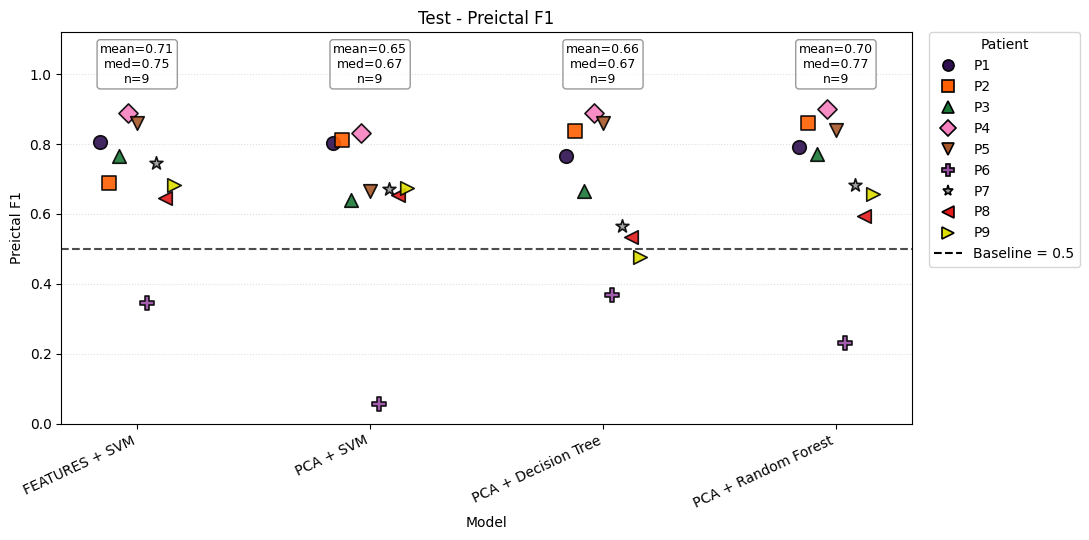


Test - Seizure F1
           model_group      mean    median  count
0       FEATURES + SVM  0.660766  0.732143      9
1            PCA + SVM  0.663144  0.694215      9
2  PCA + Decision Tree  0.675288  0.672566      9
3  PCA + Random Forest  0.693937  0.725490      9
SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Test_seizure_f1_summary_plot.svg


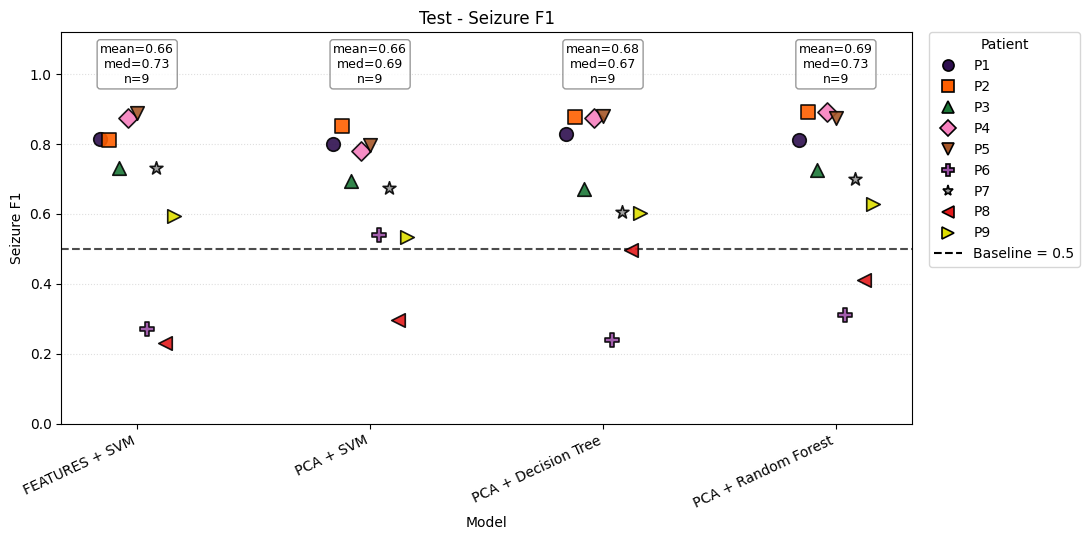

In [13]:
# TEST!!!
output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots"
)

metrics_to_plot = [
    "Weighted F1",
    "Preictal F1",
    "Seizure F1",
]

for metric_name in metrics_to_plot:
    safe_metric_name = metric_name.lower().replace(" ", "_")

    plot_metric_from_summary_long(
        summary_df_long=summary_df_long,
        metric_name=metric_name,
        dataset_to_plot="Test",
        baseline=0.5,
        output_path=output_dir / f"Test_{safe_metric_name}_summary_plot.png",
        show_plot=True
    )


Validation - Weighted F1
           model_group      mean    median  count
0       FEATURES + SVM  0.694356  0.701226      9
1            PCA + SVM  0.645362  0.671349      9
2  PCA + Decision Tree  0.676925  0.685494      9
3  PCA + Random Forest  0.676304  0.675407      9
SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Validation_weighted_f1_summary_plot.svg


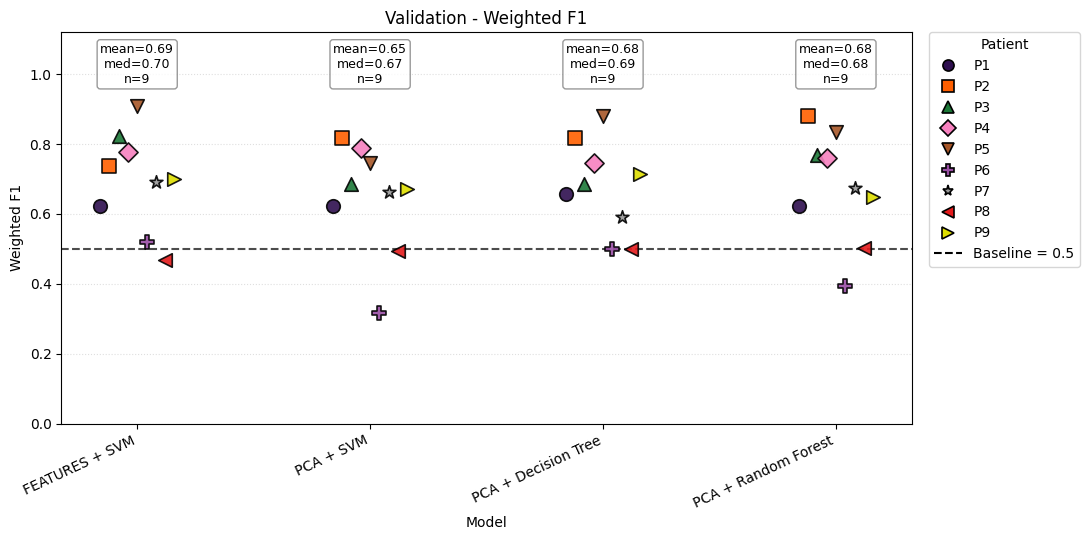


Validation - Preictal F1
           model_group      mean    median  count
0       FEATURES + SVM  0.688964  0.674157      9
1            PCA + SVM  0.609506  0.634146      9
2  PCA + Decision Tree  0.647239  0.634146      9
3  PCA + Random Forest  0.640734  0.623656      9
SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Validation_preictal_f1_summary_plot.svg


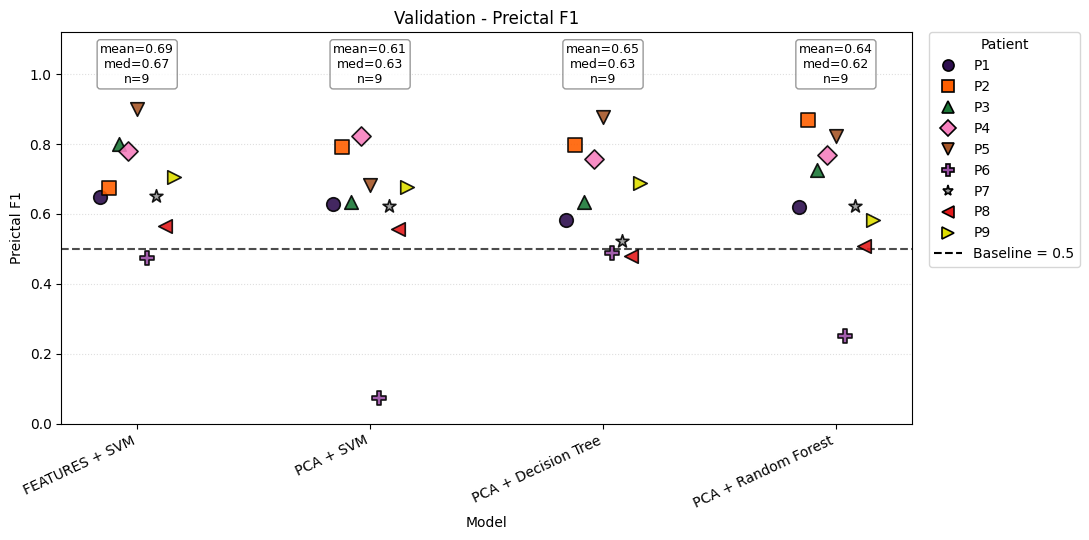


Validation - Seizure F1
           model_group      mean    median  count
0       FEATURES + SVM  0.699599  0.728745      9
1            PCA + SVM  0.680984  0.704453      9
2  PCA + Decision Tree  0.705620  0.733333      9
3  PCA + Random Forest  0.710863  0.724409      9
SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Validation_seizure_f1_summary_plot.svg


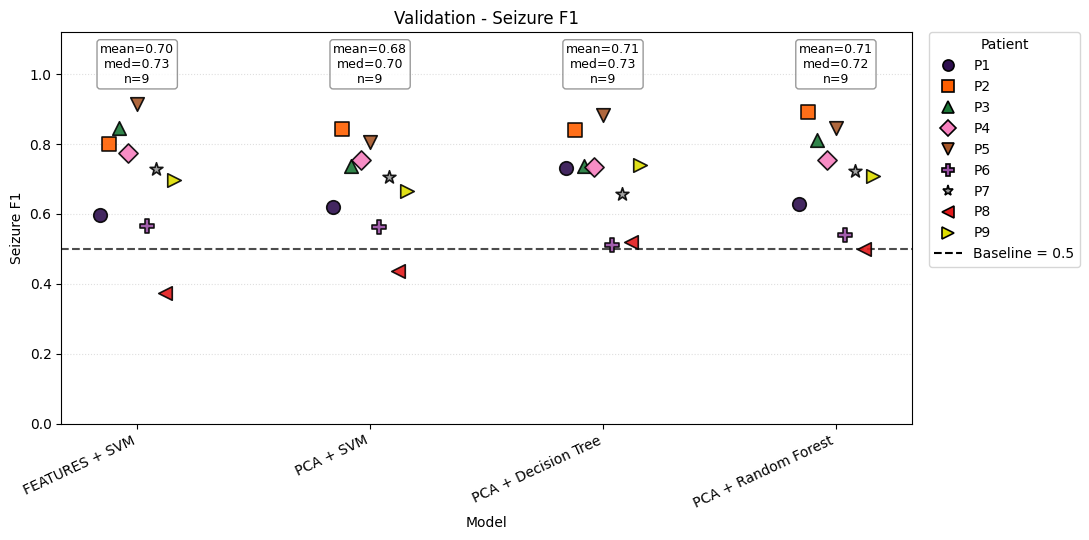

In [14]:
# VALIDATION!!
for metric_name in metrics_to_plot:
    safe_metric_name = metric_name.lower().replace(" ", "_")

    plot_metric_from_summary_long(
        summary_df_long=summary_df_long,
        metric_name=metric_name,
        dataset_to_plot="Validation",
        baseline=0.5,
        output_path=output_dir / f"Validation_{safe_metric_name}_summary_plot.png",
        show_plot=True,
        add_stats_text=True
    )

## 4. Accuracy

In [15]:
from pathlib import Path
import pandas as pd

def extract_accuracy_metric(csv_path):
    """
    Extract accuracy from one classification table CSV.
    In your CSV, the accuracy value is stored in the 'accuracy' row,
    usually under the 'f1-score' column.
    """

    csv_path = Path(csv_path)

    df = pd.read_csv(csv_path)

    # Remove accidental unnamed columns
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    if "class_or_metric" not in df.columns:
        raise ValueError(
            f"'class_or_metric' column not found in {csv_path.name}. "
            f"Columns found: {list(df.columns)}"
        )

    df["class_or_metric_clean"] = (
        df["class_or_metric"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    acc_row = df[df["class_or_metric_clean"] == "accuracy"]

    if acc_row.empty:
        raise ValueError(
            f"'accuracy' row not found in {csv_path.name}. "
            f"Rows found: {df['class_or_metric'].tolist()}"
        )

    # In your classification table, this should work
    accuracy_value = acc_row["f1-score"].iloc[0]

    return float(accuracy_value)
def build_accuracy_summary_df(metadata_df):
    """
    Builds one summary dataframe for accuracy.

    Each CSV becomes one row:
    patient_id | dataset | model_group | accuracy
    """

    summary_rows = []

    for _, row in metadata_df.iterrows():

        if row.get("parse_error", False):
            continue

        csv_path = row["filepath"]

        accuracy_value = extract_accuracy_metric(csv_path)

        summary_rows.append({
            "patient_id": row["patient_id"],
            "dataset": row["dataset"],
            "input_type": row["input_type"],
            "model": row["model"],
            "model_group": row["model_group"],
            "accuracy": accuracy_value,
            "filename": row["filename"],
            "filepath": row["filepath"]
        })

    summary_accuracy_df = pd.DataFrame(summary_rows)

    return summary_accuracy_df

In [19]:
def plot_accuracy_by_dataset(
    summary_accuracy_df,
    dataset_to_plot="Test",
    baseline=0.5,
    output_path=None,
    show_plot=True,
    add_stats_text=True,
    add_median_line=True
):
    """
    Plot accuracy for one dataset: Test or Validation.

    Each point represents one patient.

    Uses:
    - Numeric patient labels: P1-P9
    - Same patient color palette used in previous plots
    - Same circular marker for all patients
    - Fixed horizontal offset per patient to avoid overlap
    - Optional baseline at 0.5
    - Optional median line per ML model
    - Saves plot as SVG
    """

    df_plot = summary_accuracy_df.copy()

    df_plot = df_plot[
        df_plot["dataset"] == dataset_to_plot
    ].copy()

    # -------------------------------------------------
    # Convert original patient IDs to numeric patient labels
    # -------------------------------------------------

    df_plot["Patient"] = df_plot["patient_id"].map(patient_number_map)

    already_numeric_mask = df_plot["patient_id"].isin(patient_order)
    df_plot.loc[already_numeric_mask, "Patient"] = df_plot.loc[
        already_numeric_mask,
        "patient_id"
    ]

    unmapped_patients = df_plot.loc[
        df_plot["Patient"].isna(),
        "patient_id"
    ].unique()

    if len(unmapped_patients) > 0:
        print("Warning: these patient IDs were not mapped:", unmapped_patients)

    df_plot = df_plot.dropna(subset=["Patient"])

    df_plot["Patient"] = pd.Categorical(
        df_plot["Patient"],
        categories=patient_order,
        ordered=True
    )

    # -------------------------------------------------
    # Keep model order consistent
    # -------------------------------------------------

    current_order = [
        model for model in model_order
        if model in df_plot["model_group"].unique()
    ]

    df_plot["model_group"] = pd.Categorical(
        df_plot["model_group"],
        categories=current_order,
        ordered=True
    )

    df_plot = df_plot.sort_values(["model_group", "Patient"])

    # -------------------------------------------------
    # Calculate mean and median per model category
    # -------------------------------------------------

    stats_df = (
        df_plot
        .groupby("model_group", observed=True)["accuracy"]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
    )

    print(f"\nAccuracy - {dataset_to_plot}")
    print(stats_df)

    # -------------------------------------------------
    # Patient offset mapping
    # -------------------------------------------------

    present_patients = [
        patient for patient in patient_order
        if patient in df_plot["Patient"].astype(str).unique()
    ]

    if len(present_patients) == 1:
        offsets = [0]
    else:
        offsets = np.linspace(-0.16, 0.16, len(present_patients))

    patient_to_offset = {
        patient: offsets[i]
        for i, patient in enumerate(present_patients)
    }

    model_to_x = {
        model: i
        for i, model in enumerate(current_order)
    }

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 5.5))

    y_upper = 1.12
    y_stats = 1.09

    for _, row in df_plot.iterrows():

        model_group = row["model_group"]
        patient = str(row["Patient"])
        y_value = row["accuracy"]

        x_value = model_to_x[model_group] + patient_to_offset[patient]

        ax.scatter(
            x_value,
            y_value,
            marker="o",                      # same shape for all patients
            s=95,
            facecolors=patient_colors[patient],
            edgecolors="black",
            linewidths=1.0,
            alpha=0.90,
            zorder=3
        )

    # -------------------------------------------------
    # Median line per model
    # -------------------------------------------------

    if add_median_line:
        for i, model_group in enumerate(current_order):

            row = stats_df[stats_df["model_group"] == model_group]

            if row.empty:
                continue

            median_value = row["median"].iloc[0]

            ax.hlines(
                y=median_value,
                xmin=i - 0.24,
                xmax=i + 0.24,
                color="black",
                linewidth=2.0,
                alpha=0.45,
                zorder=4
            )

    # -------------------------------------------------
    # Baseline
    # -------------------------------------------------

    if baseline is not None:
        ax.axhline(
            y=baseline,
            linestyle="--",
            linewidth=1.5,
            color="black",
            alpha=0.7,
            zorder=1
        )

    # -------------------------------------------------
    # Add mean and median text above plot points
    # -------------------------------------------------

    if add_stats_text:
        for i, model_group in enumerate(current_order):

            row = stats_df[stats_df["model_group"] == model_group]

            if row.empty:
                continue

            mean_value = row["mean"].iloc[0]
            median_value = row["median"].iloc[0]
            count_value = int(row["count"].iloc[0])

            stats_text = (
                f"mean={mean_value:.2f}\n"
                f"med={median_value:.2f}\n"
                f"n={count_value}"
            )

            ax.text(
                x=i,
                y=y_stats,
                s=stats_text,
                ha="center",
                va="top",
                fontsize=9,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="gray",
                    alpha=0.8
                ),
                zorder=5
            )

    # -------------------------------------------------
    # Formatting
    # -------------------------------------------------

    ax.set_title(f"Accuracy - {dataset_to_plot}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")

    ax.set_ylim(0, y_upper)

    ax.set_xticks(range(len(current_order)))
    ax.set_xticklabels(current_order, rotation=25, ha="right")

    ax.grid(axis="y", linestyle=":", alpha=0.4)

    # -------------------------------------------------
    # Legend
    # -------------------------------------------------

    patient_handles = [
        Line2D(
            [0],
            [0],
            marker="o",                      # no different shapes
            color="w",
            markerfacecolor=patient_colors[patient],
            markeredgecolor="black",
            markeredgewidth=1.0,
            linestyle="None",
            markersize=8,
            label=patient
        )
        for patient in present_patients
    ]

    legend_handles = patient_handles.copy()

    if add_median_line:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=2.0,
                alpha=0.45,
                label="Median"
            )
        )

    if baseline is not None:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="--",
                linewidth=1.5,
                label=f"Baseline = {baseline}"
            )
        )

    ax.legend(
        handles=legend_handles,
        title="Patient",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()

    # -------------------------------------------------
    # Save as SVG
    # -------------------------------------------------

    if output_path is None:
        today = date.today().strftime("%Y-%m-%d")
        filename = (
            f"accuracy_"
            f"{clean_filename(dataset_to_plot)}_"
            f"model_comparison_patient_palette_median_line_{today}.svg"
        )
        output_path = Path.cwd() / filename
    else:
        output_path = Path(output_path)

        if output_path.suffix.lower() != ".svg":
            output_path = output_path.with_suffix(".svg")

    output_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        output_path,
        format="svg",
        bbox_inches="tight"
    )

    print(f"SVG saved in: {output_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()


Accuracy - Test
           model_group      mean    median  count
0       FEATURES + SVM  0.699090  0.750000      9
1            PCA + SVM  0.674541  0.673913      9
2  PCA + Decision Tree  0.671573  0.669643      9
3  PCA + Random Forest  0.701571  0.750000      9
SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Accuracy_Test_summary_plot.svg


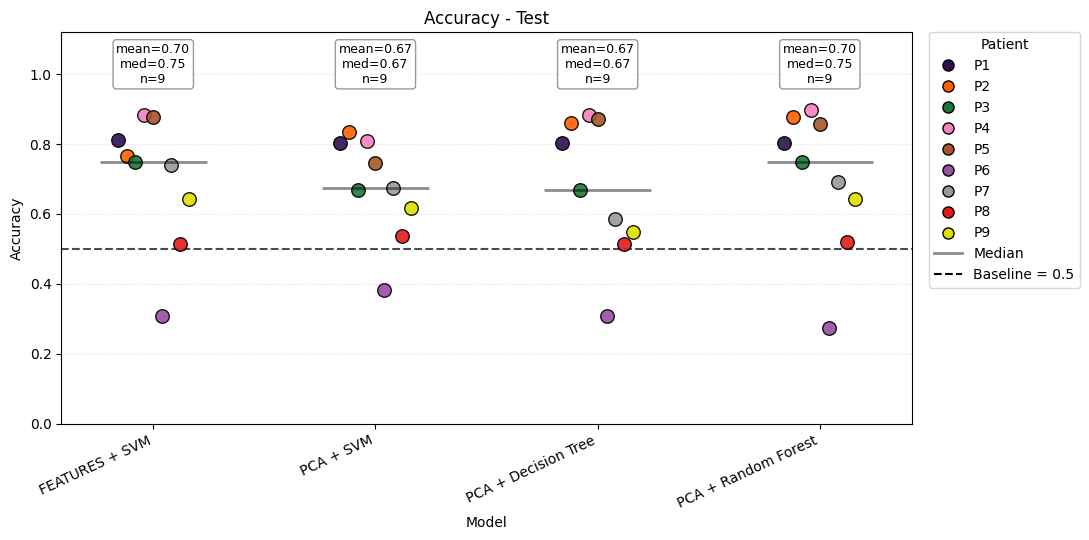


Accuracy - Validation
           model_group      mean    median  count
0       FEATURES + SVM  0.699516  0.701493      9
1            PCA + SVM  0.659907  0.671642      9
2  PCA + Decision Tree  0.681123  0.693878      9
3  PCA + Random Forest  0.682854  0.681818      9
SVG saved in: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots/Accuracy_Validation_summary_plot.svg


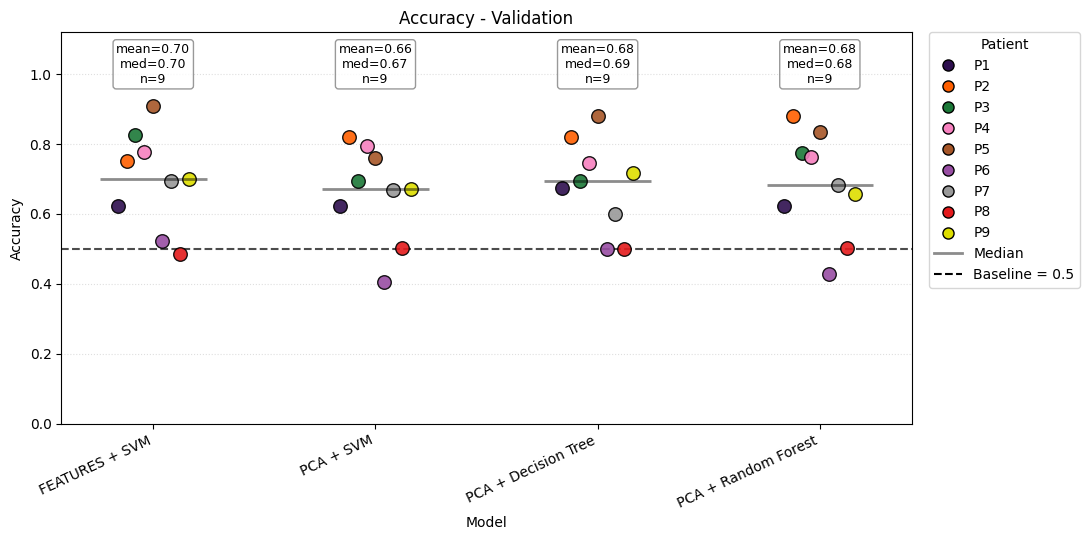

In [20]:
summary_accuracy_df = build_accuracy_summary_df(metadata_df)

summary_accuracy_df[[
    "patient_id",
    "dataset",
    "model_group",
    "accuracy",
    "filename"
]]
output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_plots"
)

for dataset_name in ["Test", "Validation"]:

    plot_accuracy_by_dataset(
        summary_accuracy_df=summary_accuracy_df,
        dataset_to_plot=dataset_name,
        baseline=0.5,
        output_path=output_dir / f"Accuracy_{dataset_name}_summary_plot.png",
        show_plot=True,
        add_stats_text=True
    )

## 5. compact table for results:


In [39]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# 1. Extract all relevant metrics from one classification table
# ============================================================

def extract_classification_metrics(csv_path):
    """
    Extract accuracy, weighted F1, preictal F1 and ictal/seizure F1
    from one classification report CSV.

    Expected rows in class_or_metric:
    - preictal
    - seizure or ictal
    - accuracy
    - weighted avg
    """

    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    # Remove accidental unnamed columns
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    if "class_or_metric" not in df.columns:
        raise ValueError(
            f"'class_or_metric' column not found in {csv_path.name}. "
            f"Columns found: {list(df.columns)}"
        )

    if "f1-score" not in df.columns:
        raise ValueError(
            f"'f1-score' column not found in {csv_path.name}. "
            f"Columns found: {list(df.columns)}"
        )

    df["class_or_metric_clean"] = (
        df["class_or_metric"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    def get_f1_from_row(row_name_options):
        """
        Extract f1-score from the first matching row.
        row_name_options can be a string or a list of strings.
        """

        if isinstance(row_name_options, str):
            row_name_options = [row_name_options]

        row_name_options = [
            str(x).strip().lower()
            for x in row_name_options
        ]

        matched_row = df[
            df["class_or_metric_clean"].isin(row_name_options)
        ]

        if matched_row.empty:
            return np.nan

        return float(matched_row["f1-score"].iloc[0])

    metrics = {
        "accuracy": get_f1_from_row("accuracy"),
        "weighted_f1": get_f1_from_row("weighted avg"),
        "preictal_f1": get_f1_from_row("preictal"),
        "ictal_f1": get_f1_from_row(["ictal", "seizure"])
    }

    return metrics


# ============================================================
# 2. Build full metrics summary dataframe
# ============================================================

def build_full_metrics_summary_df(metadata_df):
    """
    Each classification CSV becomes one row:
    patient_id | dataset | input_type | model | model_group |
    accuracy | weighted_f1 | preictal_f1 | ictal_f1
    """

    summary_rows = []

    for _, row in metadata_df.iterrows():

        if row.get("parse_error", False):
            continue

        csv_path = row["filepath"]

        metrics = extract_classification_metrics(csv_path)

        summary_rows.append({
            "patient_id": row["patient_id"],
            "dataset": row["dataset"],
            "input_type": row["input_type"],
            "model": row["model"],
            "model_group": row["model_group"],
            "accuracy": metrics["accuracy"],
            "weighted_f1": metrics["weighted_f1"],
            "preictal_f1": metrics["preictal_f1"],
            "ictal_f1": metrics["ictal_f1"],
            "filename": row["filename"],
            "filepath": row["filepath"]
        })

    summary_metrics_df = pd.DataFrame(summary_rows)

    return summary_metrics_df


# ============================================================
# 3. Create compact best-model table
# ============================================================

def build_best_model_compact_table(
    summary_metrics_df,
    dataset_to_use="Test",
    output_path=None
):
    """
    Build compact table:

    patient_id
    best_by_accuracy
    accuracy
    best_by_weighted_f1
    weighted_f1
    preictal_f1
    ictal_f1
    same_best_model

    The F1 values reported are from the model selected by weighted F1.
    """

    df = summary_metrics_df.copy()

    df = df[df["dataset"] == dataset_to_use].copy()

    if df.empty:
        raise ValueError(f"No rows found for dataset: {dataset_to_use}")

    # --------------------------------------------------------
    # Best model per patient by accuracy
    # --------------------------------------------------------

    idx_best_acc = (
        df
        .groupby("patient_id")["accuracy"]
        .idxmax()
    )

    best_acc_df = (
        df.loc[idx_best_acc, [
            "patient_id",
            "model_group",
            "accuracy"
        ]]
        .rename(columns={
            "model_group": "best_by_accuracy",
            "accuracy": "best_accuracy"
        })
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Best model per patient by weighted F1
    # --------------------------------------------------------

    idx_best_f1 = (
        df
        .groupby("patient_id")["weighted_f1"]
        .idxmax()
    )

    best_f1_df = (
        df.loc[idx_best_f1, [
            "patient_id",
            "model_group",
            "weighted_f1",
            "preictal_f1",
            "ictal_f1",
            "accuracy"
        ]]
        .rename(columns={
            "model_group": "best_by_weighted_f1",
            "accuracy": "accuracy_of_best_weighted_f1_model"
        })
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Merge both selections
    # --------------------------------------------------------

    compact_table = best_acc_df.merge(
        best_f1_df,
        on="patient_id",
        how="outer"
    )

    compact_table["same_best_model"] = (
        compact_table["best_by_accuracy"]
        == compact_table["best_by_weighted_f1"]
    )

    # --------------------------------------------------------
    # Optional: make values dissertation-friendly
    # --------------------------------------------------------

    metric_cols = [
        "best_accuracy",
        "weighted_f1",
        "preictal_f1",
        "ictal_f1",
        "accuracy_of_best_weighted_f1_model"
    ]

    for col in metric_cols:
        compact_table[col] = compact_table[col].round(3)

    compact_table = compact_table.sort_values("patient_id").reset_index(drop=True)

    # --------------------------------------------------------
    # Save if requested
    # --------------------------------------------------------

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        if output_path.suffix == ".csv":
            compact_table.to_csv(output_path, index=False)
        elif output_path.suffix in [".xlsx", ".xls"]:
            compact_table.to_excel(output_path, index=False)
        else:
            raise ValueError("output_path must end in .csv or .xlsx")

        print(f"Compact table saved to: {output_path}")

    return compact_table


# ============================================================
# 4. Run table generation
# ============================================================

summary_metrics_df = build_full_metrics_summary_df(metadata_df)

output_dir = Path(
    "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_tables"
)

compact_best_model_table = build_best_model_compact_table(
    summary_metrics_df=summary_metrics_df,
    dataset_to_use="Test",
    output_path=output_dir / "best_model_per_patient_compact_Test.csv"
)

compact_best_model_table

Compact table saved to: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/together_results/summary_tables/best_model_per_patient_compact_Test.csv


,patient_id,best_by_accuracy,best_accuracy,best_by_weighted_f1,weighted_f1,preictal_f1,ictal_f1,accuracy_of_best_weighted_f1_model,same_best_model
0,10OXG,FEATURES + SVM,0.811,FEATURES + SVM,0.811,0.807,0.814,0.811,True
1,1JSZ6,PCA + Random Forest,0.878,PCA + Random Forest,0.877,0.860,0.892,0.878,True
2,3ZL8B,FEATURES + SVM,0.750,FEATURES + SVM,0.749,0.767,0.731,0.750,True
3,F88R2,PCA + Random Forest,0.897,PCA + Random Forest,0.897,0.901,0.892,0.897,True
4,FP628,FEATURES + SVM,0.876,FEATURES + SVM,0.876,0.861,0.889,0.876,True
5,JYXFE,PCA + SVM,0.382,FEATURES + SVM,0.306,0.345,0.269,0.309,False
6,PN12G,FEATURES + SVM,0.739,FEATURES + SVM,0.739,0.746,0.732,0.739,True
7,RQXZ1,PCA + SVM,0.537,PCA + Decision Tree,0.514,0.533,0.496,0.515,False
8,XB47Y,PCA + Random Forest,0.644,PCA + Random Forest,0.641,0.658,0.629,0.644,True
